# Recurrent PCN

In [2]:
from utils.data_utils import *
from utils.preprocessing_utils import *
from PCN import *

categorical_features = [
    "L4_SRC_PORT",           
    "L4_DST_PORT",
    "PROTOCOL",              
    "L7_PROTO",
    "TCP_FLAGS",             
    "CLIENT_TCP_FLAGS",
    "SERVER_TCP_FLAGS",
    "ICMP_TYPE",             
    "ICMP_IPV4_TYPE",
    "DNS_QUERY_ID",          
    "DNS_QUERY_TYPE",        
    "FTP_COMMAND_RET_CODE"   
]

numerical_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "FLOW_DURATION_MILLISECONDS",
    "DURATION_IN",
    "DURATION_OUT",
    "MIN_TTL",                   
    "MAX_TTL",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT",
    "MIN_IP_PKT_LEN",
    "MAX_IP_PKT_LEN",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "RETRANSMITTED_IN_BYTES",
    "RETRANSMITTED_IN_PKTS",
    "RETRANSMITTED_OUT_BYTES",
    "RETRANSMITTED_OUT_PKTS",
    "SRC_TO_DST_AVG_THROUGHPUT",
    "DST_TO_SRC_AVG_THROUGHPUT",
    "NUM_PKTS_UP_TO_128_BYTES",
    "NUM_PKTS_128_TO_256_BYTES",
    "NUM_PKTS_256_TO_512_BYTES",
    "NUM_PKTS_512_TO_1024_BYTES",
    "NUM_PKTS_1024_TO_1514_BYTES",
    "TCP_WIN_MAX_IN",            
    "TCP_WIN_MAX_OUT",
    "DNS_TTL_ANSWER"             
    ]

T_infer = 100

X, y = load_dataset("archive/NF-UNSW-NB15-v2.csv")

In [3]:
removed = False
if not removed:
    X = remove_ip_fields(X)
    removed = True #we can re-run the cell
X_train, X_test, y_train, y_test = split_dataset_temporal(X, y, test_size=0.2)
X_train, y_ssl = create_ssl_dataset(X_train, y_train, label_ratio=0.9999)

print(X_train.shape)
print(y_ssl.head())
print(y_ssl.value_counts())

(1912220, 41)
0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64
Label
 0    1851824
 1      60205
-1        191
Name: count, dtype: int64


In [4]:
X_train = cap_numerical_data(X_train, numerical_features)
X_test = cap_numerical_data(X_test, numerical_features)

X_train, X_test, min_max_scaler = min_max_log_norm(X_train, X_test, numerical_features)
X_train, X_test, categories_dict = keep_top_categorical_level(X_train, X_test, categorical_features, max_levels=32)
print(categories_dict)

X_train, X_test, one_hot_encoder = ordinal_encode_categorical(X_train, X_test, categorical_features)
print(X_train.head())

{'L4_SRC_PORT': ['0', '47439', '1043', '80', '21', '6881', '53', '5190', '25', '143', '22', '1024', '111', '1669', '1114', '1155', '1250', '1418', '1243', '1405', '1084', '1408', '1116', '1035', '5060', '1920', '1701', '1607', '10472', '1301', '1751'], 'L4_DST_PORT': ['21', '53', '80', '6881', '5190', '111', '25', '143', '22', '0', '179', '445', '520', '860', '514', '1723', '110', '8089', '3260', '3354', '135', '5060', '61097', '19414', '30639', '57588', '58003', '32912', '44685', '8088', '25885'], 'PROTOCOL': ['6', '17', '89', '1', '2', '41', '132', '33', '53', '55', '77', '103', '47', '0', '3', '4', '5', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '18', '19', '20', '21'], 'L7_PROTO': ['0.0', '1.0', '7.0', '3.0', '4.0', '92.0', '17.0', '13.0', '41.0', '127.0', '131.7', '20.0', '139.0', '96.0', '2.0', '78.0', '77.0', '7.131', '50.0', '112.0', '84.0', '10.0', '100.0', '5.0', '18.0', '131.0', '161.0', '89.0', '111.0', '79.0', '164.0'], 'TCP_FLAGS': ['27', '0', '24', '25', '1

# Predictive Coding Network

In [5]:
# from torch import float32
# from torch.utils.data import DataLoader
# from PCN.trainer import train_pcn_binary


# from PCN.PCNetwork import PredictiveCodingNetwork

# device = 'cuda'
# pcn = PredictiveCodingNetwork([41, 512, 256, 128, 64, 32])
# X_tensor = torch.tensor(np.array(X_train), dtype=float32).to(device)
# print("X tensor ok")
# y_tensor = torch.tensor(np.array(y_ssl), dtype=float32).to(device)
# print("y tensor ok")
# print(X_train.shape)
# print(y_ssl.shape)

# train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=2048, shuffle=False)
# print("trainloader")
# train_pcn_binary(model=pcn, data_loader=train_loader, num_epochs=10, eta_infer=0.01, eta_learn=0.0003, T_infer=T_infer, margin_attack=200, device=device)
# torch.save(pcn.state_dict(), 'pcn_model_weights_2.pth')

/tmp/ipykernel_11195/831527869.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('pcn_model_weights_2.pth', map_location=device)
100%|██████████| 2

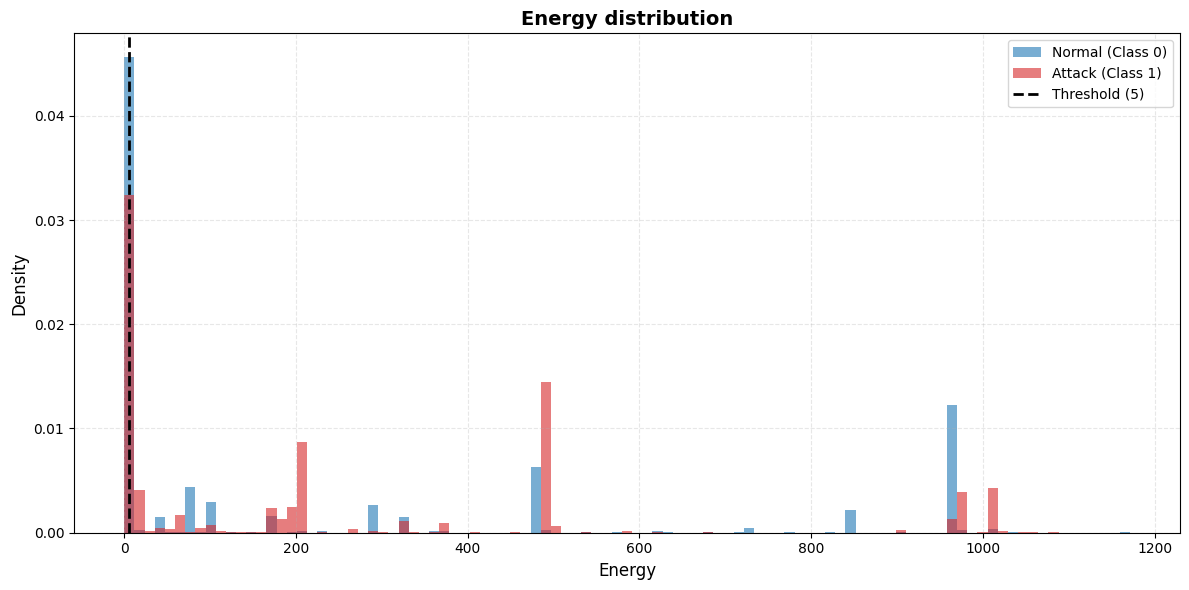


Confusion Matrix:
[[233672 209541]
 [  5866  28976]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.53      0.68    443213
         1.0       0.12      0.83      0.21     34842

    accuracy                           0.55    478055
   macro avg       0.55      0.68      0.45    478055
weighted avg       0.91      0.55      0.65    478055



(array([1.71027161e+02, 2.64754486e+00, 8.21805115e+01, ...,
        2.64971912e-01, 1.07236385e-01, 9.79692638e-02],
       shape=(478055,), dtype=float32),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(478055,), dtype=float32))

In [6]:
from utils.train_utils import  evaluate_pcn_anomaly
from PCN.PCNetwork import PredictiveCodingNetwork
device = 'cuda'

pcn_loaded = PredictiveCodingNetwork([41, 1024, 512, 256, 128])
state_dict = torch.load('pcn_model_weights_2.pth', map_location=device)
pcn_loaded.load_state_dict(state_dict)
pcn_loaded.to(device)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.float32).view(-1, 1).to(device)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=2048, shuffle=False)
pcn_loaded.eval()

evaluate_pcn_anomaly(pcn_loaded, test_loader, T_infer=T_infer, eta_infer=0.01, threshold_energy=5, device=device)